# AutoGuard — Colab inference + SAE demo

This notebook **downloads a trained AutoGuard model from GitHub** (you set the path), generates antimicrobial peptides, renders all the analysis plots, and runs the **Sparse Autoencoder (SAE)** interpretability module.

1. Set `GITHUB_REPO`, `GITHUB_BRANCH`, `REPO_SUBDIR`, `CHECKPOINT_PATH` (and optional `SAE_PATH`) in the first cell.
2. Run all cells (`Runtime -> Run all`). A GPU runtime is optional. CPU works for inference.

## 1. User configuration
Point these at **your** public GitHub repository and checkpoint.

In [1]:
# ===========================================================
# USER CONFIGURATION
# ===========================================================
GITHUB_REPO   = 'kugi8412/AutoGuard'   # public repo as "owner/name"
GITHUB_BRANCH = 'main'                 # branch or tag to clone
REPO_SUBDIR   = 'autoguard'            # folder holding the Python package

# Path for model to evaluate
CHECKPOINT_PATH = 'autoguard/checkpoints/best_model.pt'

# Optional Sparse Autoencoder checkpoint
SAE_PATH = 'autoguard/checkpoints/best_sae.pt'

# Inference settings
NUM_SAMPLES      = 100   # peptides to generate
TEMPERATURE      = 0.5   # sampling temperature (higher = more diverse)
SAFETY_THRESHOLD = 0.9   # max safety score to accept (higher = more permissive)
SEED             = 42

In [2]:
import os
import sys
import subprocess

import random
import torch

import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter


## 2. Clone the repo and install the package

In [3]:
REPO_URL = f'https://github.com/{GITHUB_REPO}.git'
REPO_DIR = GITHUB_REPO.split('/')[-1]

if not os.path.isdir(REPO_DIR):
    print(f'Cloning {REPO_URL} (branch {GITHUB_BRANCH})...')
    subprocess.run(['git', 'clone', '--depth', '1', '--branch', GITHUB_BRANCH, REPO_URL], check=True)
else:
    print(f"Repo '{REPO_DIR}' already present.")

PKG_DIR = os.path.join(REPO_DIR, REPO_SUBDIR)
print('Installing package from', PKG_DIR)
# torch is preinstalled on Colab. Graph/ESM extras are NOT needed for inference.
!pip install -q -e "{PKG_DIR}"

Cloning https://github.com/kugi8412/AutoGuard.git (branch main)...
Installing package from AutoGuard/autoguard
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.1 MB/s eta 0:00:00
  Building editable for autoguard (pyproject.toml) ... done


In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


Device: cuda


## 3. Download / locate the checkpoint

In [5]:
import urllib.request

def resolve_artifact(path_or_url, repo_dir):
    """Return a local file path for a repo-relative path or a remote URL."""
    if not path_or_url:
        return None
    if path_or_url.startswith('http://') or path_or_url.startswith('https://'):
        local = os.path.basename(path_or_url)
        print('Downloading', path_or_url)
        urllib.request.urlretrieve(path_or_url, local)
        return local
    local = os.path.join(repo_dir, path_or_url)
    if not os.path.exists(local):
        raise FileNotFoundError(f'Checkpoint not found in repo: {local}')
    return local

CKPT_LOCAL = resolve_artifact(CHECKPOINT_PATH, REPO_DIR)
print('Checkpoint:', CKPT_LOCAL)

Checkpoint: AutoGuard/autoguard/checkpoints/best_model.pt


## 4. Load the AutoGuard model

In [6]:
if 'PKG_DIR' in globals() and PKG_DIR not in sys.path:
    sys.path.append(os.path.abspath(PKG_DIR))

if 'REPO_DIR' in globals() and REPO_DIR not in sys.path:
    sys.path.append(os.path.abspath(REPO_DIR))

try:
    from autoguard.config import ModelConfig
    from autoguard.models.autoguard_model import AutoGuardModel
except ModuleNotFoundError:
    print("Still cannot find 'autoguard'. Try restarting the runtime (Runtime > Restart session) and running the cells again.")
    raise

ckpt = torch.load(CKPT_LOCAL, map_location=device, weights_only=False)
config = ckpt.get('config', ModelConfig()) if isinstance(ckpt, dict) else ModelConfig()
model = AutoGuardModel(config, use_graph_encoder=False).to(device)
state = ckpt.get('model_state_dict', ckpt) if isinstance(ckpt, dict) else ckpt
missing, unexpected = model.load_state_dict(state, strict=False)
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f'Loaded AutoGuard: {n_params:,} params | missing={len(missing)} unexpected={len(unexpected)}')


Loaded AutoGuard: 1,268,220 params | missing=0 unexpected=48


## 5. Generate peptides (inference)

In [7]:
from autoguard.data.datasets import detokenize_sequence

print(f'Generating {NUM_SAMPLES} peptides (T={TEMPERATURE}):')

sequences, metadata = model.generate(
    num_samples=NUM_SAMPLES,
    temperature=TEMPERATURE,
    safety_threshold=SAFETY_THRESHOLD,
    max_attempts=NUM_SAMPLES * 20,
)
seqs = [detokenize_sequence(s.squeeze()) for s in sequences]
keep = [(s, m) for s, m in zip(seqs, metadata) if s]
seqs = [s for s, _ in keep]
meta = [m for _, m in keep]

print(f'  Generated {len(seqs)} non-empty peptides')


Generating 100 peptides (T=0.5):
  Generated 93 non-empty peptides


In [8]:
df = pd.DataFrame({
    'sequence':     seqs,
    'length':       [len(s) for s in seqs],
    'amp_score':    [m.get('amp_score', float('nan')) for m in meta],
    'safety_score': [m.get('safety_score', float('nan')) for m in meta],
    'toxicity':     [m.get('toxicity', float('nan')) for m in meta],
    'hemolysis':    [m.get('hemolysis', float('nan')) for m in meta],
})
df.sort_values('amp_score', ascending=False).head(20)


,sequence,length,amp_score,safety_score,toxicity,hemolysis
49,GSPWPEL,7,0.921738,1.672294e-08,1.011068e-08,3.270672e-08
9,RLHRCDKK,8,0.911016,1.187784e-08,6.153128e-09,2.310168e-08
11,PRRFSGPLSFNAILPHASLPKYWKS,25,0.906092,2.629811e-08,1.847586e-08,4.815721e-08
39,DAHRYSLYNAHHFFAINFWYALIHH,25,0.900591,2.646352e-08,1.899622e-08,4.613618e-08
35,WRLTCKESNRAYCFWPYGVI,20,0.898770,2.099383e-08,1.498045e-08,3.909601e-08
53,ALPKRKKWRFCRWGRCRKFKH,21,0.891746,2.761515e-08,1.925308e-08,5.644212e-08
88,GKMEGVRKGYILGSIL,16,0.890691,1.622776e-08,8.096422e-09,2.637650e-08
10,AKIRRFFQCAPPASLQPSDNKKTQ,24,0.890651,2.044765e-08,1.319673e-08,3.905540e-08
43,TSHKSIGIPILKNAGCWAI,19,0.887404,1.711518e-08,1.083214e-08,2.909761e-08
26,ISVNPVPYQWLIVRVLPTF,19,0.877560,2.217274e-08,1.237391e-08,4.080125e-08


## 6. Plots

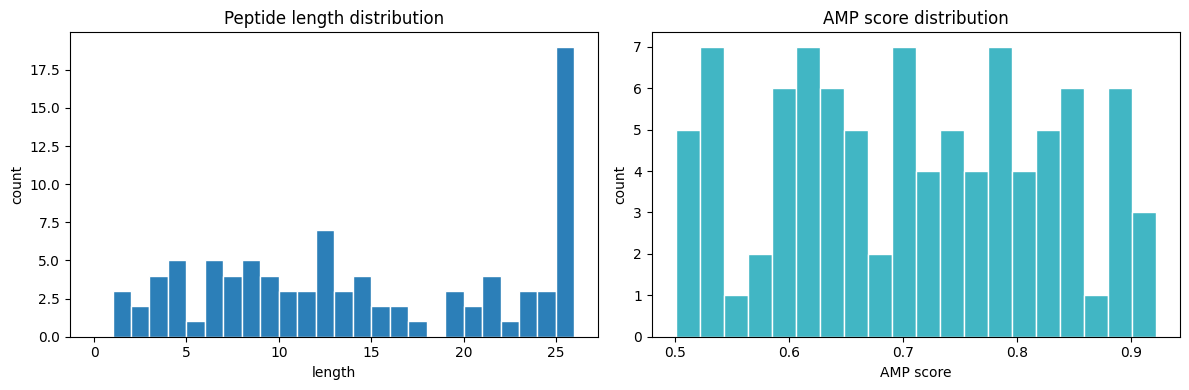

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['length'], bins=range(0, 27), color='#2c7fb8', edgecolor='white')
axes[0].set_title('Peptide length distribution')
axes[0].set_xlabel('length'); axes[0].set_ylabel('count')
axes[1].hist(df['amp_score'].dropna(), bins=20, color='#41b6c4', edgecolor='white')
axes[1].set_title('AMP score distribution')
axes[1].set_xlabel('AMP score'); axes[1].set_ylabel('count')
plt.tight_layout(); plt.show()


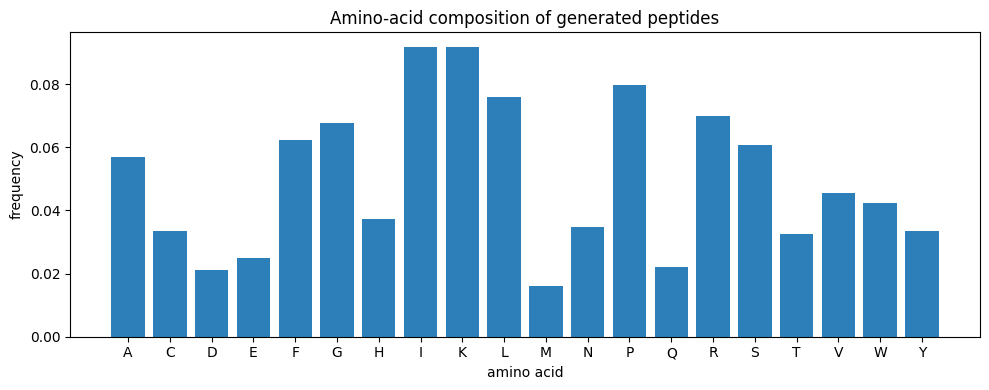

In [10]:
AA_ORDER = list('ACDEFGHIKLMNPQRSTVWY')
counts = Counter(''.join(seqs))
total = sum(counts.get(a, 0) for a in AA_ORDER) or 1
freqs = [counts.get(a, 0) / total for a in AA_ORDER]
plt.figure(figsize=(10, 4))
plt.bar(AA_ORDER, freqs, color='#2c7fb8')
plt.title('Amino-acid composition of generated peptides')
plt.ylabel('frequency'); plt.xlabel('amino acid')
plt.tight_layout(); plt.show()


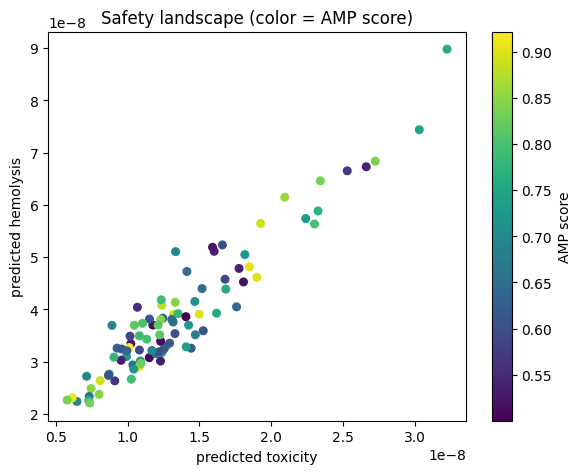

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df['toxicity'], df['hemolysis'], c=df['amp_score'], cmap='viridis', s=30)
ax.set_xlabel('predicted toxicity'); ax.set_ylabel('predicted hemolysis')
ax.set_title('Safety landscape (color = AMP score)')
plt.colorbar(sc, label='AMP score')
plt.tight_layout(); plt.show()


## 7. Sparse Autoencoder
Runs only if `SAE_PATH` is set. Collects the model's quantized activations for the generated peptides, encodes them through the SAE, and visualises the sparse feature activations.

In [12]:
features = None

if SAE_PATH:
    from autoguard.models.sparse_autoencoder import SparseAutoencoder
    from autoguard.data.datasets import tokenize_sequence

    SAE_LOCAL = resolve_artifact(SAE_PATH, REPO_DIR)
    sae_state = torch.load(SAE_LOCAL, map_location=device, weights_only=False)

    if isinstance(sae_state, dict) and 'model_state_dict' in sae_state:
        sae_state = sae_state['model_state_dict']

    hidden_dim, input_dim = sae_state['encoder.weight'].shape
    sae = SparseAutoencoder(input_dim=input_dim, hidden_dim=hidden_dim,
                            top_k=getattr(config, 'sae_top_k', 16)).to(device)
    sae.load_state_dict(sae_state)
    sae.eval()

    print(f'SAE loaded: input_dim={input_dim}, hidden_dim={hidden_dim}')
    toks = torch.stack([tokenize_sequence(s) for s in seqs]).to(device)

    with torch.no_grad():
        out = model(toks)
        acts = out['quantized']

        if acts.dim() == 3:
            acts = acts.reshape(-1, acts.shape[-1])

        features, mask = sae.encode(acts)

    feat_freq = (features > 0).float().mean(dim=0).cpu().numpy()
    dead = int((feat_freq == 0).sum())
    active = int(mask.sum(dim=1).float().mean().item())
    print(f'Features: {hidden_dim} | active per sample (top-k): {active} | dead: {dead}')
else:
    print("SAE_PATH not set so skipping SAE section.")


SAE loaded: input_dim=48, hidden_dim=96
Features: 96 | active per sample (top-k): 16 | dead: 64


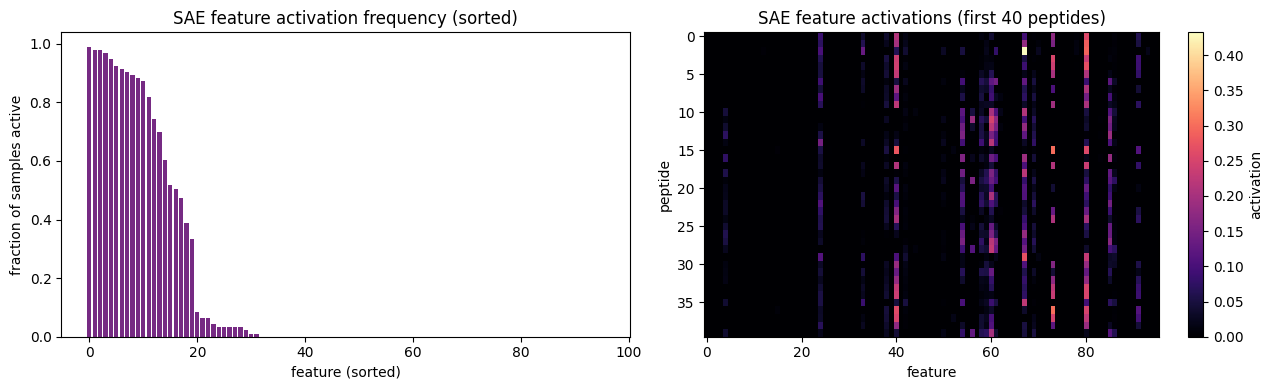

In [13]:
if features is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    order = np.argsort(feat_freq)[::-1]
    axes[0].bar(range(len(feat_freq)), feat_freq[order], color='#762a83')
    axes[0].set_title('SAE feature activation frequency (sorted)')
    axes[0].set_xlabel('feature (sorted)'); axes[0].set_ylabel('fraction of samples active')
    N = min(40, features.shape[0])
    im = axes[1].imshow(features[:N].cpu().numpy(), aspect='auto', cmap='magma')
    axes[1].set_title(f'SAE feature activations (first {N} peptides)')
    axes[1].set_xlabel('feature'); axes[1].set_ylabel('peptide')
    plt.colorbar(im, ax=axes[1], label='activation')
    plt.tight_layout(); plt.show()
else:
    print('No SAE features to plot.')


## 8. Codebook analysis (VQ-VAE)
AutoGuard's discrete bottleneck is a learned **codebook**. We encode the generated peptides, measure which codes are used, and visualise the codebook itself.

In [14]:
from autoguard.data.datasets import tokenize_sequence

mdev = next(model.parameters()).device  # keep tokens on the model's device
code_toks = torch.stack([tokenize_sequence(s) for s in seqs]).to(mdev)

with torch.no_grad():
    enc = model(code_toks)

idx = enc['encoding_info']['encoding_indices'].flatten().cpu().numpy()

num_codes = model.vector_quantizer.num_embeddings
hist = np.bincount(idx, minlength=num_codes).astype(float)
used = int((hist > 0).sum())
probs = hist / hist.sum()
nz = probs[probs > 0]
entropy = float(-(nz * np.log(nz)).sum())
max_ent = float(np.log(num_codes))
print(f'Codebook utilization: {used}/{num_codes} codes used ({100*used/num_codes:.1f}%)')
print(f'Normalized entropy: {entropy/max_ent:.3f}  |  perplexity: {np.exp(entropy):.1f}')


Codebook utilization: 138/1024 codes used (13.5%)
Normalized entropy: 0.443  |  perplexity: 21.5


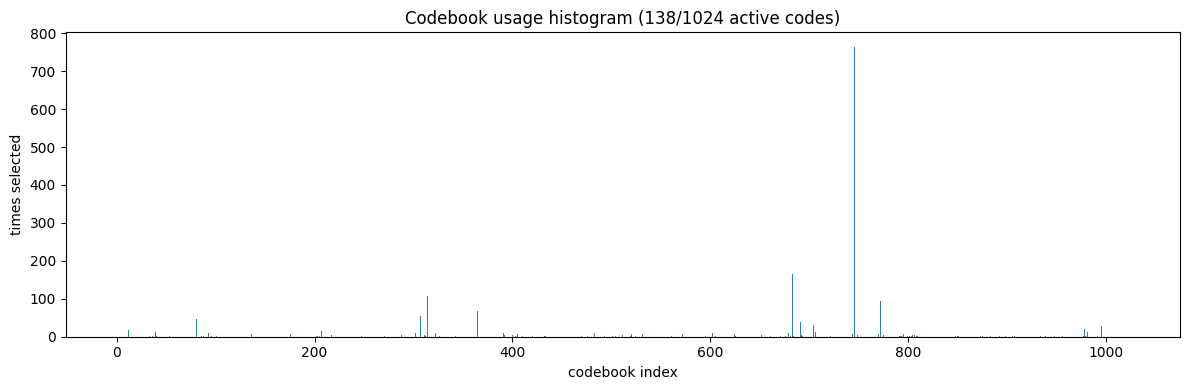

In [15]:
plt.figure(figsize=(12, 4))
plt.bar(range(num_codes), hist, color='#2c7fb8')
plt.title(f'Codebook usage histogram ({used}/{num_codes} active codes)')
plt.xlabel('codebook index'); plt.ylabel('times selected')
plt.tight_layout(); plt.show()


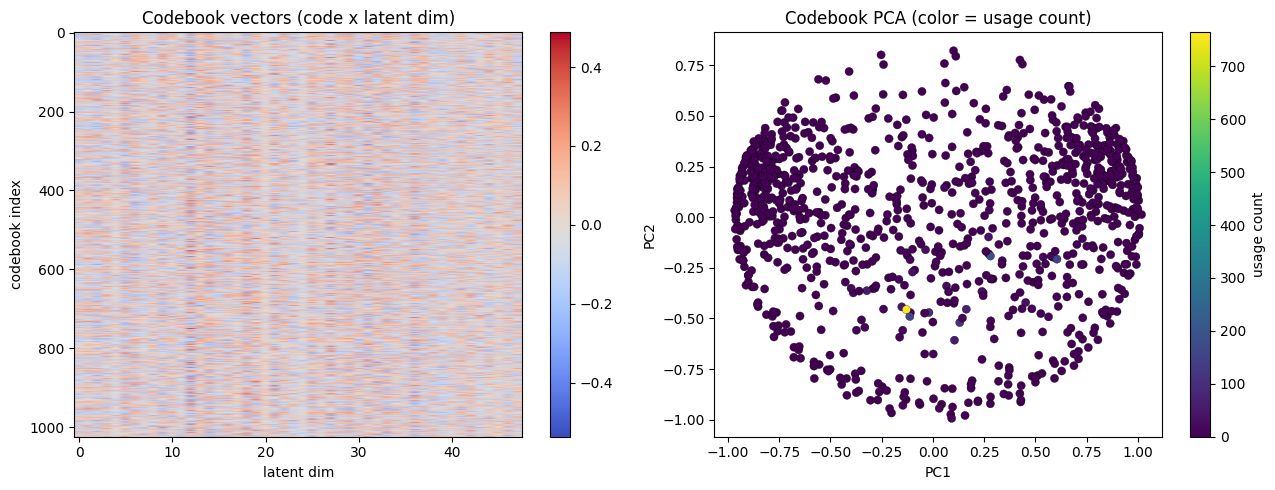

In [16]:
from sklearn.decomposition import PCA

cb = model.vector_quantizer.embedding.weight.detach().cpu().numpy()  # [num_codes, dim]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im = axes[0].imshow(cb, aspect='auto', cmap='coolwarm')
axes[0].set_title('Codebook vectors (code x latent dim)')
axes[0].set_xlabel('latent dim'); axes[0].set_ylabel('codebook index')
plt.colorbar(im, ax=axes[0])
emb2d = PCA(n_components=2).fit_transform(cb)
sc = axes[1].scatter(emb2d[:, 0], emb2d[:, 1], c=hist, cmap='viridis', s=35, edgecolor='k', linewidth=0.2)
axes[1].set_title('Codebook PCA (color = usage count)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc, ax=axes[1], label='usage count')
plt.tight_layout(); plt.show()


## 9. XAI
Gradient-based explainability: which residues drive the **AMP** and **safety** predictions. A forward hook captures the embedding actually used in the forward pass, so the attribution is exact and device-safe.

In [17]:
def residue_saliency(model, sequence, target='amp'):
    """Per-residue gradient saliency. target: 'amp' or 'safety'. Device-safe."""
    dev = next(model.parameters()).device
    model.eval()
    tokens = tokenize_sequence(sequence).unsqueeze(0).to(dev)
    captured = {}

    def hook(module, inp, out):
        out.retain_grad(); captured['emb'] = out

    handle = model.seq_encoder.embedding.register_forward_hook(hook)
    model.zero_grad()
    out = model(tokens)
    score = out['safety']['safety_score'].mean() if target == 'safety' else out['amp_prediction'].mean()
    score.backward()
    handle.remove()
    sal = captured['emb'].grad[0, :len(sequence)].norm(dim=-1)
    sal = sal.detach().cpu().numpy()
    return sal / (sal.max() + 1e-8)


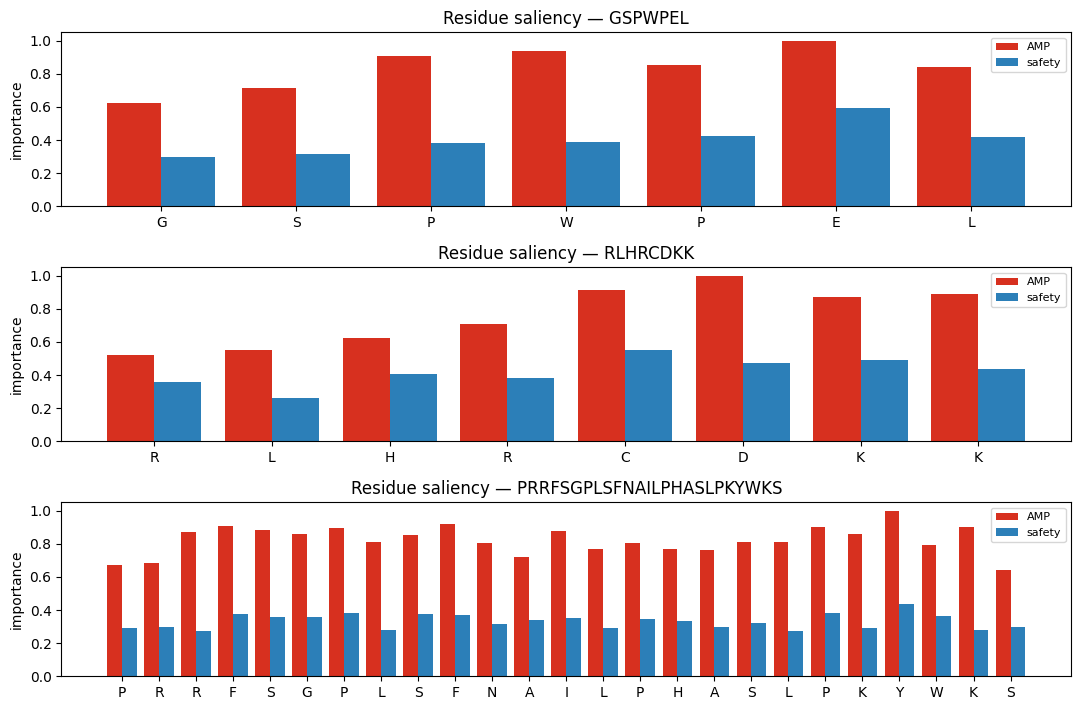

In [18]:
top_seqs = df.sort_values('amp_score', ascending=False).head(3)['sequence'].tolist()
fig, axes = plt.subplots(len(top_seqs), 1, figsize=(11, 2.4 * len(top_seqs)))

if len(top_seqs) == 1:
    axes = [axes]

for ax, sq in zip(axes, top_seqs):
    amp_sal = residue_saliency(model, sq, 'amp')
    saf_sal = residue_saliency(model, sq, 'safety')
    xpos = np.arange(len(sq))
    ax.bar(xpos - 0.2, amp_sal, width=0.4, color='#d7301f', label='AMP')
    ax.bar(xpos + 0.2, saf_sal, width=0.4, color='#2c7fb8', label='safety')
    ax.set_xticks(xpos); ax.set_xticklabels(list(sq))
    ax.set_title(f'Residue saliency \u2014 {sq}')
    ax.set_ylabel('importance'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

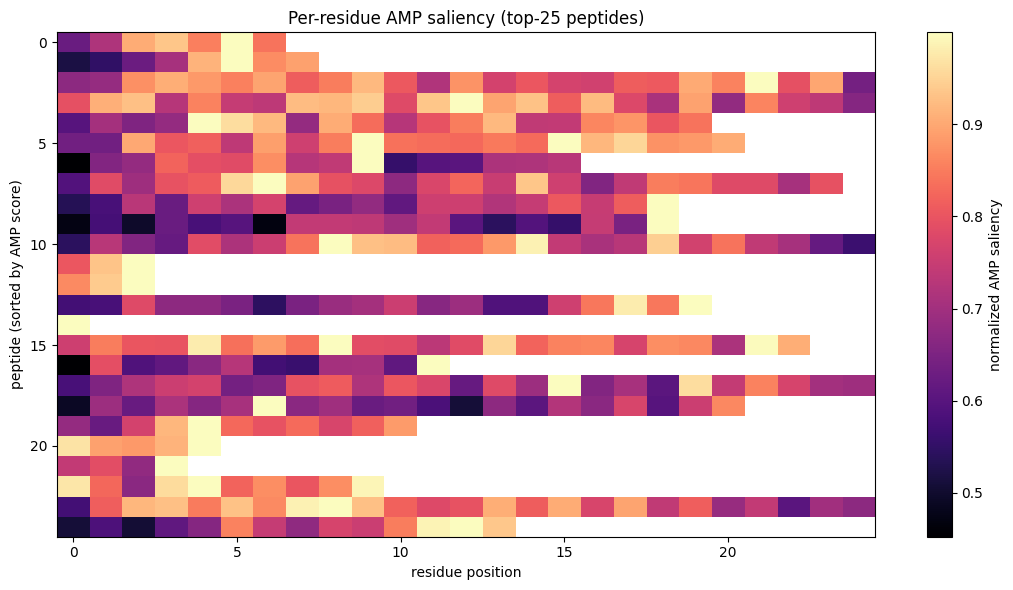

In [19]:
# Saliency heatmap across many peptides (positions 0..L-1, AMP target)
sample_seqs = df.sort_values('amp_score', ascending=False).head(25)['sequence'].tolist()
maxlen = max(len(s) for s in sample_seqs)
heat = np.full((len(sample_seqs), maxlen), np.nan)

for r, sq in enumerate(sample_seqs):
    heat[r, :len(sq)] = residue_saliency(model, sq, 'amp')

plt.figure(figsize=(11, 6))
plt.imshow(heat, aspect='auto', cmap='magma')
plt.colorbar(label='normalized AMP saliency')
plt.title('Per-residue AMP saliency (top-25 peptides)')
plt.xlabel('residue position'); plt.ylabel('peptide (sorted by AMP score)')
plt.tight_layout()
plt.show()


## 10. Save results

In [20]:
"""
out_csv = 'autoguard_generated.csv'
df.to_csv(out_csv, index=False)
with open('autoguard_generated.fasta', 'w') as f:
    for i, s in enumerate(seqs):
        f.write(f'>autoguard_{i}\n{s}\n')
print('Saved:', out_csv, 'and autoguard_generated.fasta')
try:
    from google.colab import files
    files.download(out_csv)
except Exception:
    pass
"""

print("That's all folks!")


That's all folks!
